In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from skmap.misc import find_files, GoogleSheet, ttprint
import warnings
import multiprocess as mp
import time
from scipy.special import expit, logit
import warnings
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, HalvingGridSearchCV, KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
import joblib
import pickle
from sklearn.metrics import r2_score, mean_squared_error, make_scorer#, root_mean_squared_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
# from cubist import Cubist
from sklearn.base import BaseEstimator, TransformerMixin
from pathlib import Path
from trees_rf import TreesRandomForestRegressor
from model_fit import read_features, cfi_calc, parameter_fine_tuning, calc_ccc, separate_data, rscfi 
from model_fit import accuracy_plot, plot_top_features, pdp_hexbin, plot_histogram, calc_metrics, accuracy_strata_plot
import warnings
warnings.filterwarnings('ignore')
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import json
from datetime import datetime

folder_path = '/mnt/ripley/global_soc/scikit-map/global-soil-mapping'
# prop_list = ['ocd', 'soc', 'bulk.density', 'ph.h2o' ,'coarse']
prop_list = ['bulk.density',]

transforms_dict = {
    'ocd': 'log1p',
    'soc': 'log1p',
    'bulk.density': None,
    'ph.h2o': None,
    'coarse': 'log1p'
}
version = '20250204'

# generate the production model with all the data we have

In [2]:
for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    df = pd.read_parquet(f'{folder_path}/material/soil_pnts_organized_v{version}.pq')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space == 'log1p':
        df[f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space == 'boxcox':
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    covs = read_features(f'{output_folder}/feature_selected_{prop}_v{version}.txt')  # Read in
    
    model = joblib.load(f'{output_folder}/model_rf.{prop}_ccc_v{version}.joblib')
    model.n_jobs = 90
    
    # Drop rows with NaN values in the target column
    df = df.dropna(subset=[tgt])
    df = df.reset_index(drop=True)
    y = df[tgt]
    X = df[covs]
    
    nan_percentage = (X.isna().sum() / len(X)) * 100
    nan_percentage = nan_percentage.sort_values(ascending=False)
    print("\nNaN Percentage per Column (Sorted):")
    for nn, (col, perc) in enumerate(nan_percentage.items()):
        print(f"{col}: {perc:.2f}%")
        if nn > 10:
            break
    
    print(f"Number of samples: {X.shape[0]}")
    X_np = X.to_numpy()
    print(f"Number of covariates: {len(covs)}")
    print(f"Percentage of NaN in X: {np.sum(np.sum(np.isnan(X_np))) / X_np.size * 100:.2f}%, filling them with median")
   
    X = X.fillna(X.median())
    model.fit(X, y)
    
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    print(f"R² score on the training set: {r2:.4f}")
    
    joblib.dump(model, f'{folder_path}/production/model_rf.{prop}_production_v{version}_check.joblib')


bulk.density--------------------------------------------------------------

NaN Percentage per Column (Sorted):
clm_lst_mod11a2.nighttime_p05_1km_s0..0cm_YYYY.05.01..YYYY.05.31_v1.2: 1.35%
clm_lst_mod11a2.daytime_p50_1km_s0..0cm_YYYY.05.01..YYYY.05.31_v1.2: 1.35%
clm_lst_mod11a2.daytime_p95_1km_s0..0cm_YYYY.06.01..YYYY.06.30_v1.2: 1.35%
clm_lst_mod11a2.daytime_p05_1km_s0..0cm_YYYY.06.01..YYYY.06.30_v1.2: 1.35%
clm_lst_mod11a2.daytime_p95_1km_s0..0cm_YYYY.08.01..YYYY.08.31_v1.2: 1.35%
clm_lst_mod11a2.daytime_p50_1km_s0..0cm_YYYY.09.01..YYYY.09.30_v1.2: 1.35%
clm_lst_mod11a2.nighttime_p05_1km_s0..0cm_YYYY.08.01..YYYY.08.31_v1.2: 1.35%
clm_lst_mod11a2.nighttime_p50_1km_s0..0cm_YYYY.06.01..YYYY.06.30_v1.2: 1.35%
clm_lst_mod11a2.nighttime_p95_1km_s0..0cm_YYYY.05.01..YYYY.05.31_v1.2: 1.35%
clm_lst_mod11a2.daytime_p95_1km_s0..0cm_YYYY.09.01..YYYY.09.30_v1.2: 1.35%
swir2_glad.swa.ard2_p25_30m_s_YYYY0101_YYYY1231_go_epsg.4326_v1: 1.01%
swir1_glad.swa.ard2_p25_30m_s_YYYY0101_YYYY1231_go_epsg.43

In [3]:
y_pred

array([1.46386348, 1.39243938, 1.46760856, ..., 1.26226447, 1.52170776,
       1.73364331])

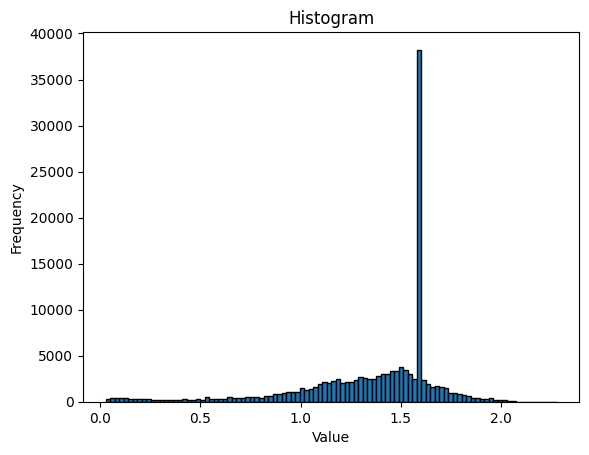

In [4]:
import matplotlib.pyplot as plt

plt.hist(y_pred, bins=100, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()


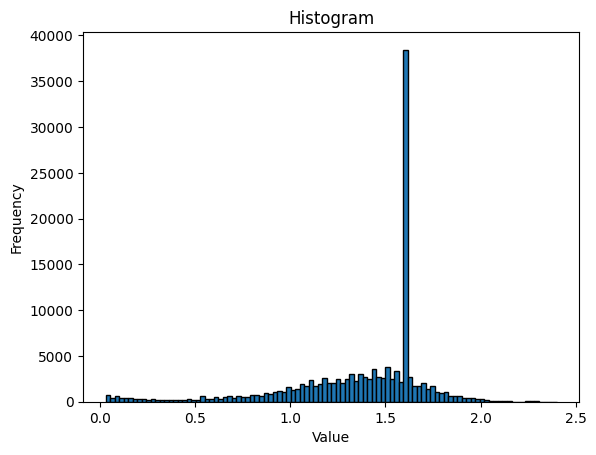

In [5]:
import matplotlib.pyplot as plt

plt.hist(y, bins=100, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()


In [27]:
df_save = df.copy()

from shapely.geometry import Point
from geopandas import gpd 
geometry = [Point(xy) for xy in zip(df_save['lon'], df_save['lat'])]
df_save = gpd.GeoDataFrame(df_save, geometry=geometry, crs="EPSG:4326")

df_save = df_save[['geometry', 'bulk.density', 'year','hzn_dep']]
df_save['bulk.density.pred'] = y_pred

df_save = df_save.loc[df_save['year']==2020]
df_save = df_save.loc[df_save['hzn_dep']==15.0]

In [29]:
df_save.to_file("bd.gpkg", layer='layer_name', driver="GPKG")

In [28]:
df_save

,geometry,bulk.density,year,hzn_dep,bulk.density.pred
131557,POINT (-72.82627 -14.78544),1.6,2020,15.0,1.600000
131558,POINT (-68.15019 -19.06014),1.6,2020,15.0,1.591094
131559,POINT (48.63427 30.18872),1.6,2020,15.0,1.599958
131560,POINT (43.02845 12.70465),1.6,2020,15.0,1.599958
131561,POINT (43.36747 12.23654),1.6,2020,15.0,1.599958
...,...,...,...,...,...
131794,POINT (131.77473 -31.72365),1.6,2020,15.0,1.600011
131795,POINT (123.00717 -32.61374),1.6,2020,15.0,1.600000
131796,POINT (35.62220 36.63712),1.6,2020,15.0,1.602531
131797,POINT (-16.47919 66.04544),1.6,2020,15.0,1.600000


In [30]:
f'{folder_path}/production/model_rf.{prop}_production_v{version}_check.joblib'

'/mnt/ripley/global_soc/scikit-map/global-soil-mapping/production/model_rf.bulk.density_production_v20250204_check.joblib'